# Statistical Validation of the Hillstrom A/B Test

## Introduction

The first notebook established that the email campaigns produced different business outcomes.

This notebook goes deeper.

The goal is to determine whether the observed differences are:

- statistically reliable
- practically meaningful
- estimated with reasonable uncertainty
- robust to multiple comparisons
- sufficiently powered

The analysis will cover:

1. Confidence intervals
2. Absolute lift
3. Relative lift
4. Effect size
5. Multiple comparison correction
6. Statistical power
7. Minimum detectable effect
8. Revenue uncertainty

The business question is no longer only:

> Did the campaign perform better?

The stronger question is:

> How large is the effect, how certain are we, and is the effect large enough to matter?

In [36]:
# core data tools
import pandas as pd
import numpy as np

# statistical tools
from scipy import stats

from statsmodels.stats.proportion import (
    proportions_ztest,
    proportion_confint,
    proportion_effectsize
)

from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import NormalIndPower

# visualiztion
import matplotlib.pyplot as plt
import seaborn as sns

# Improve notebook display formatting
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

Load data

In [4]:
# load cleaned Hillstrom dataset
DATA_PATH = "../data/processed/hillstrom_cleaned.csv"

df = pd.read_csv(DATA_PATH)

# preview data
df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.440000,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.000000
1,6,3) $200 - $350,329.080000,1,1,Rural,1,Web,No E-Mail,0,0,0.000000
2,7,2) $100 - $200,180.650000,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.000000
3,9,5) $500 - $750,675.830000,1,0,Rural,1,Web,Mens E-Mail,0,0,0.000000
4,2,1) $0 - $100,45.340000,1,0,Urban,0,Web,Womens E-Mail,0,0,0.000000


Validate data

In [5]:
# confirm expected dataset structure

print("Dataset shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Experiment groups:", df["segment"].unique())

Dataset shape: (64000, 12)
Missing values: 0
Experiment groups: ['Womens E-Mail' 'No E-Mail' 'Mens E-Mail']


Create Groups

In [6]:
# Split data into experiment groups

mens_email = df[df["segment"]== "Mens E-Mail"].copy()
womens_email = df[df["segment"]=="Womens E-Mail"].copy()
control = df[df["segment"]=="No E-Mail"].copy()

# confirm group sizes
print("Mens E-Mail:", len(mens_email))
print("Womens E-Mail:", len(womens_email))
print("No E-Mail:", len(control))

Mens E-Mail: 21307
Womens E-Mail: 21387
No E-Mail: 21306


## 1. Confidence Intervals for Conversion Rates

A p-value tells us whether an observed difference is statistically unusual under the null hypothesis.

However, it does not tell us the plausible range of the true conversion rate.

A 95% confidence interval gives us a range of values that are compatible with the observed data under the chosen statistical procedure.

This helps answer:

> How precisely do we know each group's conversion rate?

In [7]:
# Create a reusable function for conversion rate confidence intervals
def conversion_ci(data, alpha=0.05):
    """
    Calculate conversion rate and 95% confidence interval.

    Parameters
    ----------
    data : pd.DataFrame
        Experiment group data containing a conversion column.
    alpha : float
        Significance level.

    Returns
    -------
    tuple
        Conversion rate, lower confidence bound, upper confidence bound.
    """

    conversions = int(data["conversion"].sum())
    n = len(data)

    lower, upper = proportion_confint(
        count=conversions,
        nobs=n,
        alpha=alpha,
        method="wilson"
    )

    conversion_rate = conversions / n

    return conversion_rate, lower, upper

Wilson Score ("wilson")Developed by Edwin Bidwell Wilson, this method inverts the score test instead of the Wald test
- Pros:Excellent Balance:
- Widely considered one of the best overall methods. It maintains superb coverage properties even for small sample sizes or extreme probabilities.
- Boundaries Respected: Automatically bounds the interval within $[0, 1]$.
- Asymmetric: Properly reflects the asymmetry of the distribution when $p$ is close to 0 or 1.
- Cons:Complex Formula:
- The algebraic formula is messy and less intuitive to write out by hand compared to the Wald or Agresti-Coull methods.

#### Calculate confidence intervals

In [8]:
# calculate conversion rate confidence intervals

mens_rate, mens_lower, mens_upper = conversion_ci(mens_email)
womens_rate, womens_lower, womens_upper = conversion_ci(womens_email)
control_rate, control_lower, control_upper = conversion_ci(control)

In [9]:
conversion_ci_summary = pd.DataFrame({
    "segment": [
        "Mens E-Mail",
        "Womens E-Mail",
        "No E-Mail"
    ],
    "conversion_rate": [
    mens_rate,
    womens_rate,
    control_rate
    ],
    "ci_lower": [
        mens_lower,
        womens_lower,
        control_lower
    ],
    "ci_upper": [
        mens_upper,
        womens_upper,
        control_upper
    ]
})

conversion_ci_summary

,segment,conversion_rate,ci_lower,ci_upper
0,Mens E-Mail,0.012531,0.011123,0.014115
1,Womens E-Mail,0.008837,0.007668,0.010183
2,No E-Mail,0.005726,0.004798,0.006832


In [10]:
# Create a readable percentage version
conversion_ci_display = conversion_ci_summary.copy()

for column in ["conversion_rate", "ci_lower", "ci_upper"]:
    conversion_ci_display[column] = (
        conversion_ci_display[column] * 100
    ).round(3)

conversion_ci_display

,segment,conversion_rate,ci_lower,ci_upper
0,Mens E-Mail,1.253000,1.112000,1.412000
1,Womens E-Mail,0.884000,0.767000,1.018000
2,No E-Mail,0.573000,0.480000,0.683000


In [ ]:
# Calculate asymmetric error bars
lower_error = (
    conversion_ci_summary["conversion_rate"]
    - conversion_ci_summary["ci_lower"]
)

upper_error = (
    conversion_ci_summary["ci_upper"]
    - conversion_ci_summary["conversion_rate"]
)

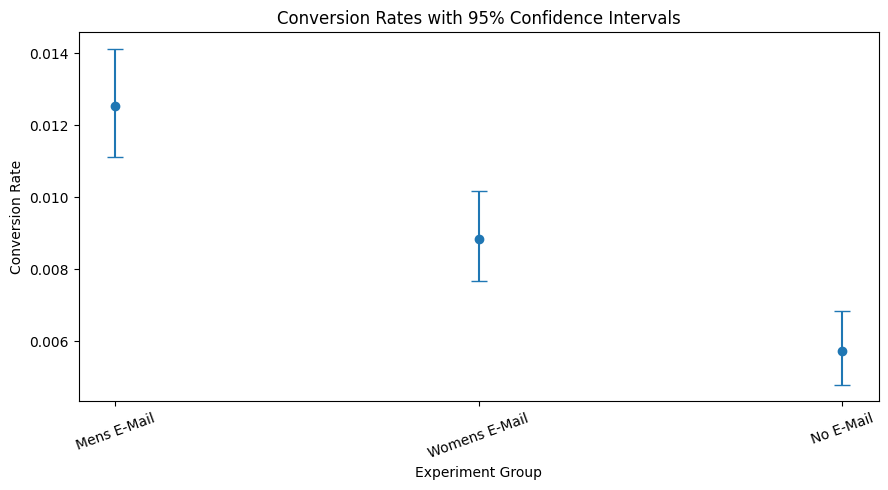

In [ ]:
# Plot conversion rates with 95% confidence intervals
plt.figure(figsize=(9, 5))

plt.errorbar(
    x=conversion_ci_summary["segment"],
    y=conversion_ci_summary["conversion_rate"],
    yerr=[lower_error, upper_error],
    fmt="o",
    capsize=6
)

plt.title("Conversion Rates with 95% Confidence Intervals")
plt.xlabel("Experiment Group")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Statistical Interpretation

The Mens E-Mail campaign produced the highest observed conversion rate at approximately **1.253%**, with a 95% Wilson confidence interval of roughly **1.112% to 1.412%**.

The Womens E-Mail campaign produced a conversion rate of approximately **0.884%**, with a 95% confidence interval of roughly **0.767% to 1.018%**.

The No E-Mail control group had the lowest conversion rate at approximately **0.573%**, with a 95% confidence interval of roughly **0.480% to 0.683%**.

The Mens E-Mail confidence interval lies clearly above the control interval, providing strong evidence that the Mens E-Mail campaign improved conversion.

The Womens E-Mail campaign also performed above control. Although its effect is smaller than the Mens E-Mail campaign, the estimated conversion improvement remains meaningful.

### Business Implication

The uncertainty analysis supports the earlier business conclusion:

> Mens E-Mail is the strongest campaign, while Womens E-Mail also appears to create positive conversion lift relative to sending no email.

The key advantage of confidence intervals is that they show not only the estimated result, but also the plausible range of the true underlying conversion rate.

### Interpretation

The confidence intervals provide a more complete view than conversion rates alone.

The Mens E-Mail group has the highest observed conversion rate, while the No E-Mail control group has the lowest.

The confidence intervals help show the uncertainty around these estimates.

A narrow interval indicates greater precision, while a wider interval indicates more uncertainty.

Because the sample contains tens of thousands of customers, the experiment can estimate relatively small conversion rates with useful precision.

## 2. Absolute and Relative Conversion Lift

Statistical significance alone is not enough.

We also need to measure the size of the improvement.

### Absolute Lift

Absolute lift measures the percentage-point difference:

> Treatment conversion rate - Control conversion rate

### Relative Lift

Relative lift measures the proportional improvement:

> (Treatment rate - Control rate) / Control rate

These answer different business questions.

Absolute lift tells us how many additional conversions occur per customer exposed.

Relative lift tells us how large the improvement is compared with the baseline.

In [12]:
# Calculate absolute lift
mens_absolute_lift = mens_rate - control_rate
womens_absolute_lift = womens_rate - control_rate

# Calculate relative lift
mens_relative_lift = mens_absolute_lift / control_rate
womens_relative_lift = womens_absolute_lift / control_rate

In [13]:
lift_summary = pd.DataFrame({
    "campaign": [
        "Mens E-Mail",
        "Womens E-Mail"
    ],
    "treatment_conversion_rate": [
        mens_rate,
        womens_rate
    ],
    "control_conversion_rate": [
        control_rate,
        control_rate
    ],
    "absolute_lift": [
        mens_absolute_lift,
        womens_absolute_lift
    ],
    "relative_lift": [
        mens_relative_lift,
        womens_relative_lift
    ]
})

lift_summary

,campaign,treatment_conversion_rate,control_conversion_rate,absolute_lift,relative_lift
0,Mens E-Mail,0.012531,0.005726,0.006805,1.188422
1,Womens E-Mail,0.008837,0.005726,0.003111,0.543313


Readable lift table

In [14]:
# Format lift metrics for business interpretation
lift_display = lift_summary.copy()

lift_display["treatment_conversion_rate"] = (
    lift_display["treatment_conversion_rate"] * 100
).round(3)

lift_display["control_conversion_rate"] = (
    lift_display["control_conversion_rate"] * 100
).round(3)

lift_display["absolute_lift"] = (
    lift_display["absolute_lift"] * 100
).round(3)

lift_display["relative_lift"] = (
    lift_display["relative_lift"] * 100
).round(2)

lift_display

,campaign,treatment_conversion_rate,control_conversion_rate,absolute_lift,relative_lift
0,Mens E-Mail,1.253000,0.573000,0.681000,118.840000
1,Womens E-Mail,0.884000,0.573000,0.311000,54.330000


### Lift Interpretation

The Mens E-Mail campaign increased conversion by approximately **0.681 percentage points** compared with the No E-Mail control group.

Although 0.681 percentage points may initially appear small, the baseline conversion rate is only about 0.573%. Relative to that baseline, the Mens E-Mail campaign produced an improvement of approximately **118.84%**.

This means the observed conversion rate was more than double the control baseline.

The Womens E-Mail campaign increased conversion by approximately **0.311 percentage points**, corresponding to a relative lift of approximately **54.33%** over control.

### Business Implication

The Mens E-Mail campaign generated the strongest practical improvement.

The key lesson is that absolute and relative lift must be interpreted together:

- Absolute lift shows the direct change in conversion probability.
- Relative lift shows how large the improvement is compared with the baseline.

Because the baseline conversion rate is low, even a sub-one-percentage-point absolute increase can represent a substantial proportional improvement and meaningful business value at scale.

## 3. Effect Size

Large sample sizes can make small differences statistically significant.

Effect size helps separate:

> statistically detectable

from:

> practically meaningful

For two proportions, we use Cohen's h.

This gives a standardized measure of the difference between two conversion rates.

In [16]:
# Calculate standardized effect size for two proportions
mens_effect_size = proportion_effectsize(
    mens_rate,
    control_rate
)

womens_effect_size = proportion_effectsize(
    womens_rate,
    control_rate
)

In [17]:
effect_size_summary = pd.DataFrame({
    "campaign": [
        "Mens E-Mail",
        "Womens E-Mail"
    ],
    "cohens_h": [
        mens_effect_size,
        womens_effect_size
    ]
})

effect_size_summary

,campaign,cohens_h
0,Mens E-Mail,0.072868
1,Womens E-Mail,0.036804


Effect size classification

In [18]:
# Create a simple effect size interpretation function
def classify_effect_size(effect_size):
    """
    Classify Cohen's h using common benchmark thresholds.
    """

    value = abs(effect_size)

    if value < 0.2:
        return "Small"
    elif value < 0.5:
        return "Medium"
    else:
        return "Large"


effect_size_summary["interpretation"] = (
    effect_size_summary["cohens_h"]
    .apply(classify_effect_size)
)

effect_size_summary

,campaign,cohens_h,interpretation
0,Mens E-Mail,0.072868,Small
1,Womens E-Mail,0.036804,Small


### Effect Size Interpretation

Both campaigns have a small standardized effect size according to conventional Cohen's h benchmarks.

- Mens E-Mail: approximately **0.073**
- Womens E-Mail: approximately **0.037**

The Mens E-Mail campaign has nearly twice the standardized effect size of the Womens E-Mail campaign.

However, the classification of both effects as "small" should not be interpreted as "unimportant."

In large-scale marketing systems, a small per-customer effect can create substantial aggregate value when applied across tens of thousands or millions of customers.

### Business Implication

This experiment demonstrates an important distinction:

> Statistical effect size and economic value are not the same thing.

The campaign effect may be small in standardized statistical terms while still producing meaningful incremental revenue.

For this reason, campaign decisions should combine:

- effect size
- conversion lift
- customer volume
- incremental revenue
- campaign cost

## 4. Multiple Comparison Correction

This experiment compares two treatment campaigns against the same control group:

1. Mens E-Mail vs No E-Mail
2. Womens E-Mail vs No E-Mail

Running multiple hypothesis tests increases the chance of obtaining a false positive.

To control this risk, we apply multiple-testing corrections.

We will compare:

- Raw p-values
- Bonferroni correction
- Benjamini-Hochberg correction

### Recalculate p-values

In [19]:
# Mens E-Mail vs control
mens_count = np.array([
    mens_email["conversion"].sum(),
    control["conversion"].sum()
])

mens_nobs = np.array([
    len(mens_email),
    len(control)
])

z_mens, p_mens = proportions_ztest(
    mens_count,
    mens_nobs
)

In [20]:
# Womens E-Mail vs control
womens_count = np.array([
    womens_email["conversion"].sum(),
    control["conversion"].sum()
])

womens_nobs = np.array([
    len(womens_email),
    len(control)
])

z_womens, p_womens = proportions_ztest(
    womens_count,
    womens_nobs
)


In [21]:
raw_p_values = np.array([
    p_mens,
    p_womens
])

raw_p_values

array([1.52322350e-13, 1.57105129e-04])

Bonferroni correction

In [22]:
# Apply Bonferroni correction
bonferroni_results = multipletests(
    raw_p_values,
    alpha=0.05,
    method="bonferroni"
)

bonferroni_results

(array([ True,  True]),
 array([3.04644700e-13, 3.14210258e-04]),
 np.float64(0.025320565519103666),
 0.025)

Benjamini-Hochberg correction

In [23]:
# Apply Benjamini-Hochberg false discovery rate correction
fdr_results = multipletests(
    raw_p_values,
    alpha=0.05,
    method="fdr_bh"
)

fdr_results

(array([ True,  True]),
 array([3.04644700e-13, 1.57105129e-04]),
 np.float64(0.025320565519103666),
 0.025)

Comparison table

In [37]:
# Create a readable multiple-testing display
multiple_testing_display = multiple_testing_summary.copy()

for column in [
    "raw_p_value",
    "bonferroni_p_value",
    "fdr_p_value"
]:
    multiple_testing_display[column] = (
        multiple_testing_display[column]
        .map(lambda x: f"{x:.3e}")
    )

multiple_testing_display

,comparison,raw_p_value,bonferroni_p_value,bonferroni_significant,fdr_p_value,fdr_significant
0,Mens E-Mail vs No E-Mail,1.523e-13,3.046e-13,True,3.046e-13,True
1,Womens E-Mail vs No E-Mail,1.571e-04,3.142e-04,True,1.571e-04,True


### Multiple Testing Interpretation

Both campaign comparisons remain statistically significant after correcting for multiple hypothesis tests.

The Mens E-Mail comparison has an extremely small raw p-value, approximately **1.52 × 10⁻¹³**.

The Womens E-Mail comparison has a raw p-value of approximately **0.000157**.

After applying the conservative Bonferroni correction:

- Mens E-Mail remains statistically significant.
- Womens E-Mail remains statistically significant.

The Benjamini-Hochberg false discovery rate correction leads to the same overall conclusion.

### Business Implication

The campaign findings are not artifacts of running multiple comparisons.

Even after adjusting for the increased false-positive risk, both campaigns retain statistical evidence of improved conversion relative to the No E-Mail control group.

The Mens E-Mail campaign remains the strongest treatment.

## 5. Statistical Power Analysis

Statistical power measures the probability that an experiment will detect a real effect when the effect truly exists.

A common target is:

> 80% power

Low-powered experiments are risky because a real business effect may exist but remain undetected.

Power depends on:

- sample size
- effect size
- significance level
- allocation ratio

### Achieved power

In [25]:
# Initialize power analysis tool
power_analysis = NormalIndPower()

# Calculate achieved power for Mens E-Mail vs control
mens_power = power_analysis.power(
    effect_size=abs(mens_effect_size),
    nobs1=len(mens_email),
    alpha=0.05,
    ratio=len(control) / len(mens_email),
    alternative="two-sided"
)

In [28]:
# Calculate achieved power for Womens E-Mail vs control
womens_power = power_analysis.power(
    effect_size=abs(womens_effect_size),
    nobs1=len(womens_email),
    alpha=0.05,
    ratio=len(control) / len(womens_email),
    alternative="two-sided"
)

In [29]:
power_summary = pd.DataFrame({
    "campaign": [
        "Mens E-Mail",
        "Womens E-Mail"
    ],
    "achieved_power": [
        mens_power,
        womens_power
    ]
})

In [27]:
power_summary

,campaign,achieved_power
0,Mens E-Mail,1.000000
1,Womens E-Mail,0.967281


### Power Analysis Interpretation

The experiment achieved very high statistical power for both treatment comparisons.

- Mens E-Mail achieved approximately **100% power**
- Womens E-Mail achieved approximately **96.7% power**

Both values exceed the commonly used 80% target.

This means the experiment had a strong probability of detecting effects of the observed magnitude.

### Business Implication

The results are unlikely to be explained by an underpowered experiment.

The large sample sizes of approximately 21,000 customers per group provide strong statistical sensitivity.

This increases confidence that the detected campaign effects are real rather than simply missed or unstable signals caused by insufficient sample size.

## 6. Minimum Detectable Effect

The Minimum Detectable Effect, or MDE, is the smallest standardized effect that the current sample size can reliably detect at the chosen power and significance level.

We use:

- 80% target power
- 5% significance level

This helps answer:

> With the sample size available, how sensitive is this experiment?

In [30]:
# Approximate balanced sample size using treatment and control groups
nobs1 = len(mens_email)
ratio = len(control) / len(mens_email)

# Solve for minimum detectable standardized effect
mde_effect_size = power_analysis.solve_power(
    effect_size=None,
    nobs1=nobs1,
    alpha=0.05,
    power=0.80,
    ratio=ratio,
    alternative="two-sided"
)

print(f"Minimum detectable standardized effect: {mde_effect_size:.6f}")

Minimum detectable standardized effect: 0.027143


### Minimum Detectable Effect Interpretation

With the available sample size, 5% significance level, and 80% target power, the experiment can detect a standardized effect of approximately **0.027** or larger.

This indicates that the experiment is sensitive to relatively small treatment effects.

The observed Mens E-Mail effect size of approximately **0.073** is well above this threshold.

The observed Womens E-Mail effect size of approximately **0.037** is also above the threshold.

### Business Implication

The experiment was sufficiently sensitive to detect both observed campaign effects.

This is important because it shows that the statistical conclusions are supported not only by p-values, but also by the experiment's ability to detect small effects.

## 7. Bootstrap Confidence Interval for Revenue Lift

Conversion is not the only business outcome.

The company ultimately cares about revenue.

Customer spending is usually highly skewed:

- many customers spend zero
- a small number spend much more

Because of this shape, bootstrap resampling is useful for estimating uncertainty around average spend lift.

We will estimate a 95% bootstrap confidence interval for:

> Treatment average spend - Control average spend

In [31]:
# Create bootstrap function for difference in average spend
def bootstrap_spend_lift(
    treatment,
    control,
    n_bootstrap=5000,
    random_state=42
):
    """
    Bootstrap the difference in average spend between
    treatment and control groups.
    """

    rng = np.random.default_rng(random_state)

    treatment_values = treatment["spend"].to_numpy()
    control_values = control["spend"].to_numpy()

    bootstrap_differences = []

    for _ in range(n_bootstrap):

        treatment_sample = rng.choice(
            treatment_values,
            size=len(treatment_values),
            replace=True
        )

        control_sample = rng.choice(
            control_values,
            size=len(control_values),
            replace=True
        )

        difference = (
            treatment_sample.mean()
            - control_sample.mean()
        )

        bootstrap_differences.append(difference)

    return np.array(bootstrap_differences)

Mens bootstrap

In [32]:
# Bootstrap Mens E-Mail spend lift
mens_bootstrap_lift = bootstrap_spend_lift(
    treatment=mens_email,
    control=control
)

mens_bootstrap_lift[:10]

array([0.70908568, 1.00866672, 0.80015063, 0.73768323, 0.73791018,
       0.82778137, 0.74202987, 0.85926599, 0.57683693, 0.79488433])

Mens CI

In [33]:
# Calculate 95% bootstrap confidence interval
mens_spend_lower = np.percentile(
    mens_bootstrap_lift,
    2.5
)

mens_spend_upper = np.percentile(
    mens_bootstrap_lift,
    97.5
)

mens_spend_mean_lift = mens_bootstrap_lift.mean()

print(f"Estimated average spend lift: ${mens_spend_mean_lift:.4f}")
print(f"95% Bootstrap CI: (${mens_spend_lower:.4f}, ${mens_spend_upper:.4f})")

Estimated average spend lift: $0.7701
95% Bootstrap CI: ($0.4791, $1.0492)


### Mens E-Mail Revenue Lift Interpretation

The bootstrap analysis estimates that the Mens E-Mail campaign increased average customer spend by approximately **$0.77 per assigned customer** relative to the No E-Mail control group.

The 95% bootstrap confidence interval ranges from approximately:

- **$0.48**
- to **$1.05**

Importantly, the entire interval is above zero.

This provides evidence that the positive spend lift is not driven only by random sampling variation.

### Business Implication

The Mens E-Mail campaign appears to generate genuine incremental revenue.

At scale, an average increase of approximately $0.77 per customer can become financially meaningful when the campaign reaches tens of thousands or millions of customers.

Womens bootstrap

In [34]:
# Bootstrap Womens E-Mail spend lift
womens_bootstrap_lift = bootstrap_spend_lift(
    treatment=womens_email,
    control=control
)

womens_spend_lower = np.percentile(
    womens_bootstrap_lift,
    2.5
)

womens_spend_upper = np.percentile(
    womens_bootstrap_lift,
    97.5
)

womens_spend_mean_lift = womens_bootstrap_lift.mean()

print(f"Estimated average spend lift: ${womens_spend_mean_lift:.4f}")
print(f"95% Bootstrap CI: (${womens_spend_lower:.4f}, ${womens_spend_upper:.4f})")

Estimated average spend lift: $0.4234
95% Bootstrap CI: ($0.1588, $0.6844)


### Womens E-Mail Revenue Lift Interpretation

The bootstrap analysis estimates that the Womens E-Mail campaign increased average customer spend by approximately **$0.42 per assigned customer** relative to the No E-Mail control group.

The 95% bootstrap confidence interval ranges from approximately:

- **$0.16**
- to **$0.68**

The entire interval is above zero.

This indicates that the Womens E-Mail campaign also produced positive incremental spend.

### Business Implication

The Womens E-Mail campaign creates measurable financial value, but the estimated lift is smaller than the Mens E-Mail campaign.

The overall ranking therefore remains:

1. Mens E-Mail
2. Womens E-Mail
3. No E-Mail

Bootstrap chart

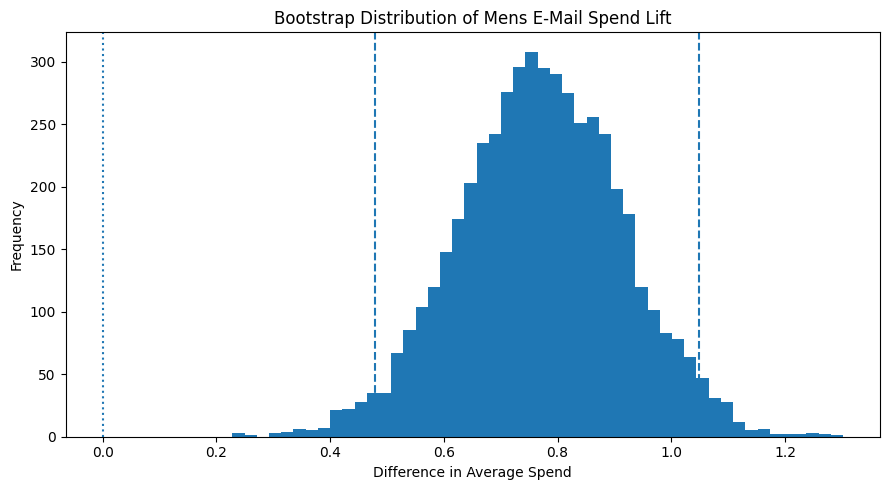

In [35]:
# Plot bootstrap distribution for Mens E-Mail spend lift
plt.figure(figsize=(9, 5))

plt.hist(
    mens_bootstrap_lift,
    bins=50
)

plt.axvline(
    mens_spend_lower,
    linestyle="--"
)

plt.axvline(
    mens_spend_upper,
    linestyle="--"
)

plt.axvline(
    0,
    linestyle=":"
)

plt.title("Bootstrap Distribution of Mens E-Mail Spend Lift")
plt.xlabel("Difference in Average Spend")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Minimum Detectable Effect Interpretation

With the available sample size, 5% significance level, and 80% target power, the experiment can detect a standardized effect of approximately **0.027** or larger.

This indicates that the experiment is sensitive to relatively small treatment effects.

The observed Mens E-Mail effect size of approximately **0.073** is well above this threshold.

The observed Womens E-Mail effect size of approximately **0.037** is also above the threshold.

### Business Implication

The experiment was sufficiently sensitive to detect both observed campaign effects.

This is important because it shows that the statistical conclusions are supported not only by p-values, but also by the experiment's ability to detect small effects.

# Final Statistical Validation

The statistical validation strengthens the original A/B test findings.

The analysis examined:

- conversion confidence intervals
- absolute conversion lift
- relative conversion lift
- standardized effect size
- multiple comparison correction
- statistical power
- minimum detectable effect
- bootstrap uncertainty for revenue lift

## Main Business Conclusion

The Mens E-Mail campaign remains the strongest candidate because it combines:

1. Higher observed conversion
2. Stronger absolute lift
3. Stronger relative lift
4. Higher incremental revenue
5. Strong performance across customer segments

However, this notebook adds an important principle:

> A campaign should not be selected based on p-value alone.

A strong experiment decision should combine:

Statistical significance  
→ effect size  
→ uncertainty  
→ power  
→ revenue impact  
→ business cost

## Next Analytical Step

The next step is to move from:

> Which campaign works on average?

to:

> Which individual customers are most likely to benefit from treatment?

That requires uplift modeling and heterogeneous treatment effect analysis.